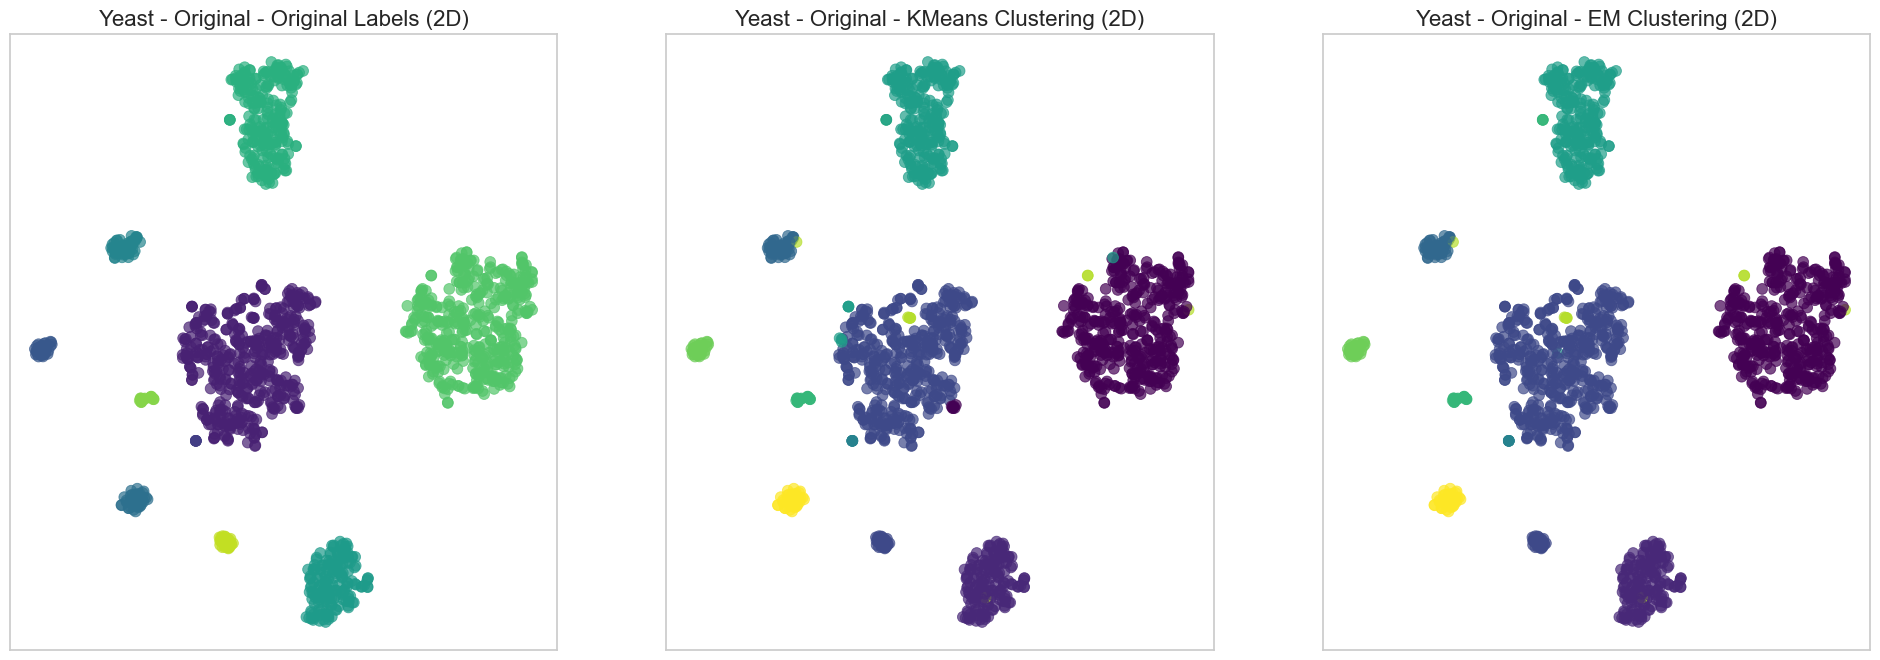

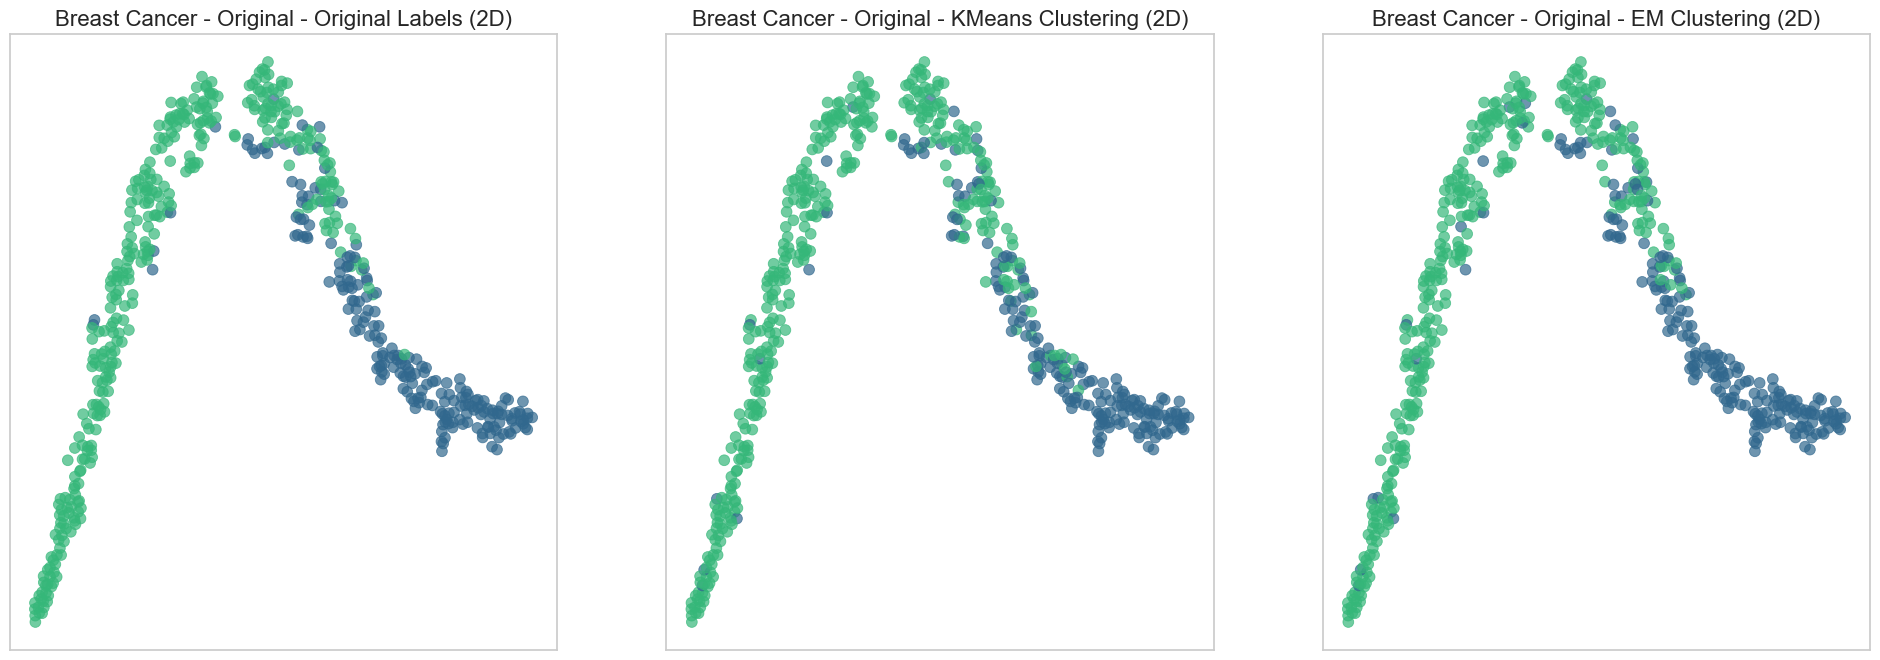

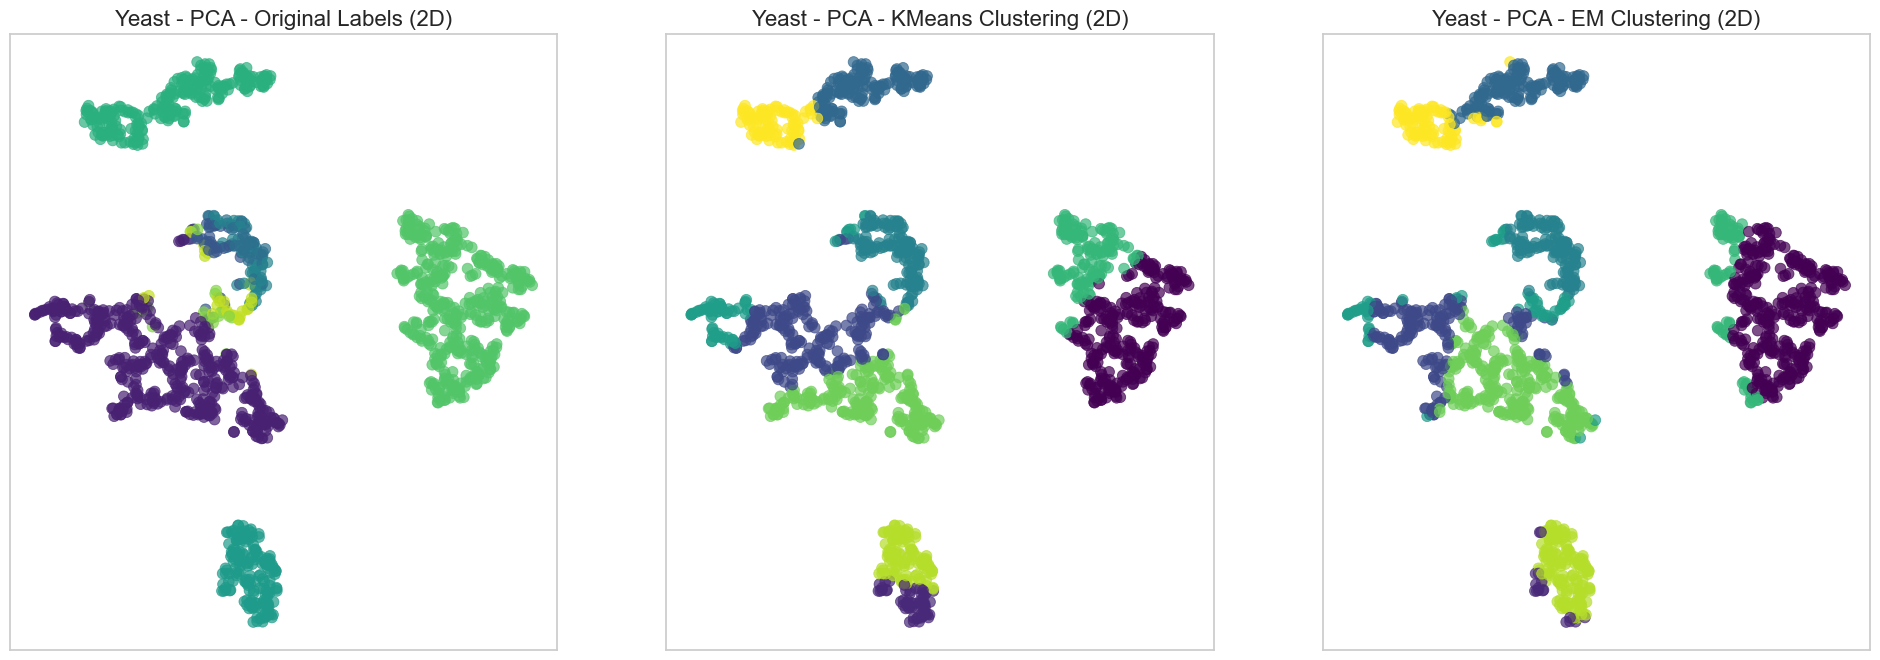

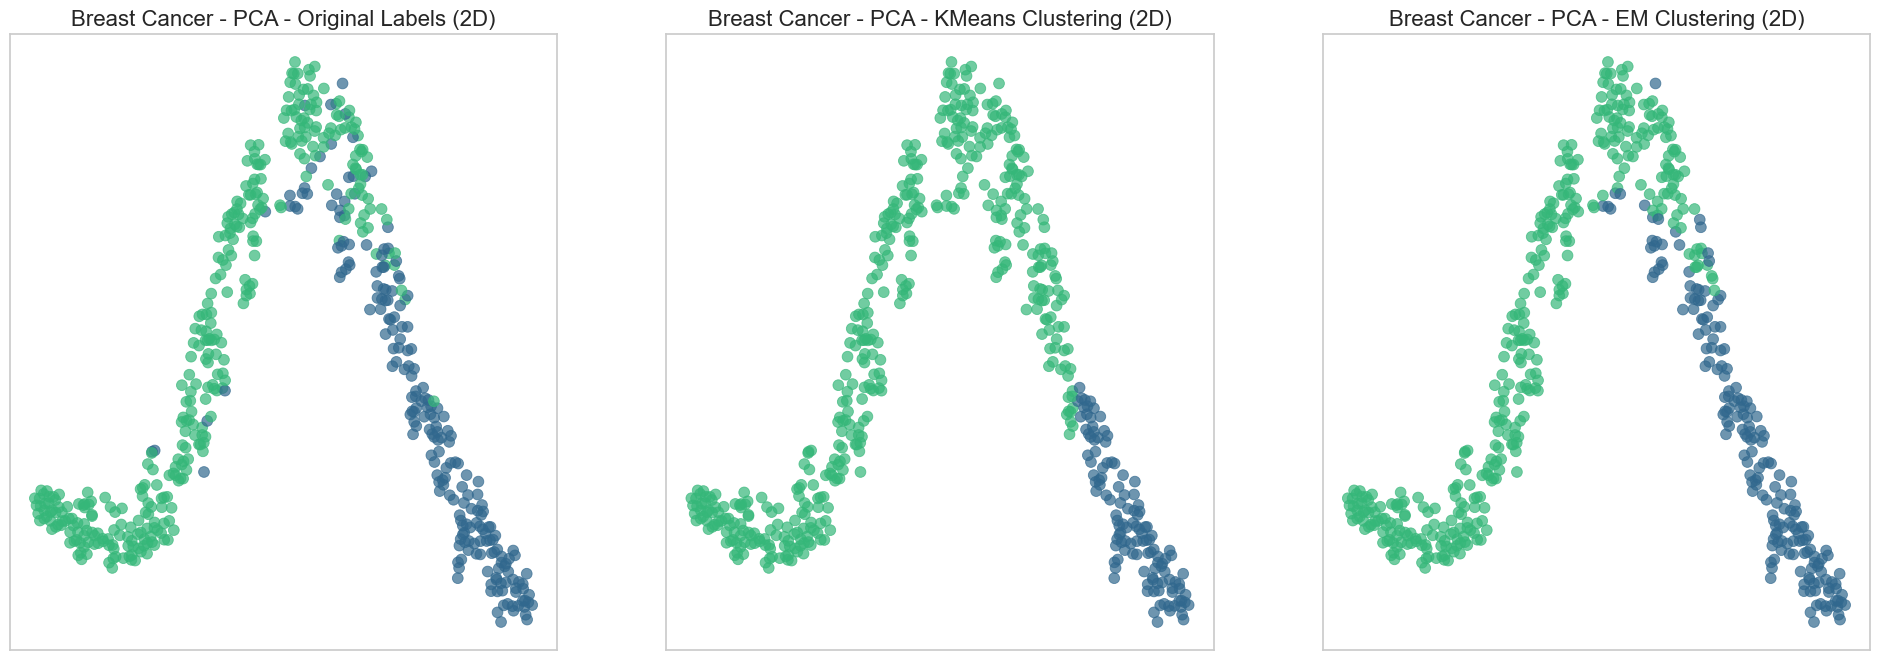

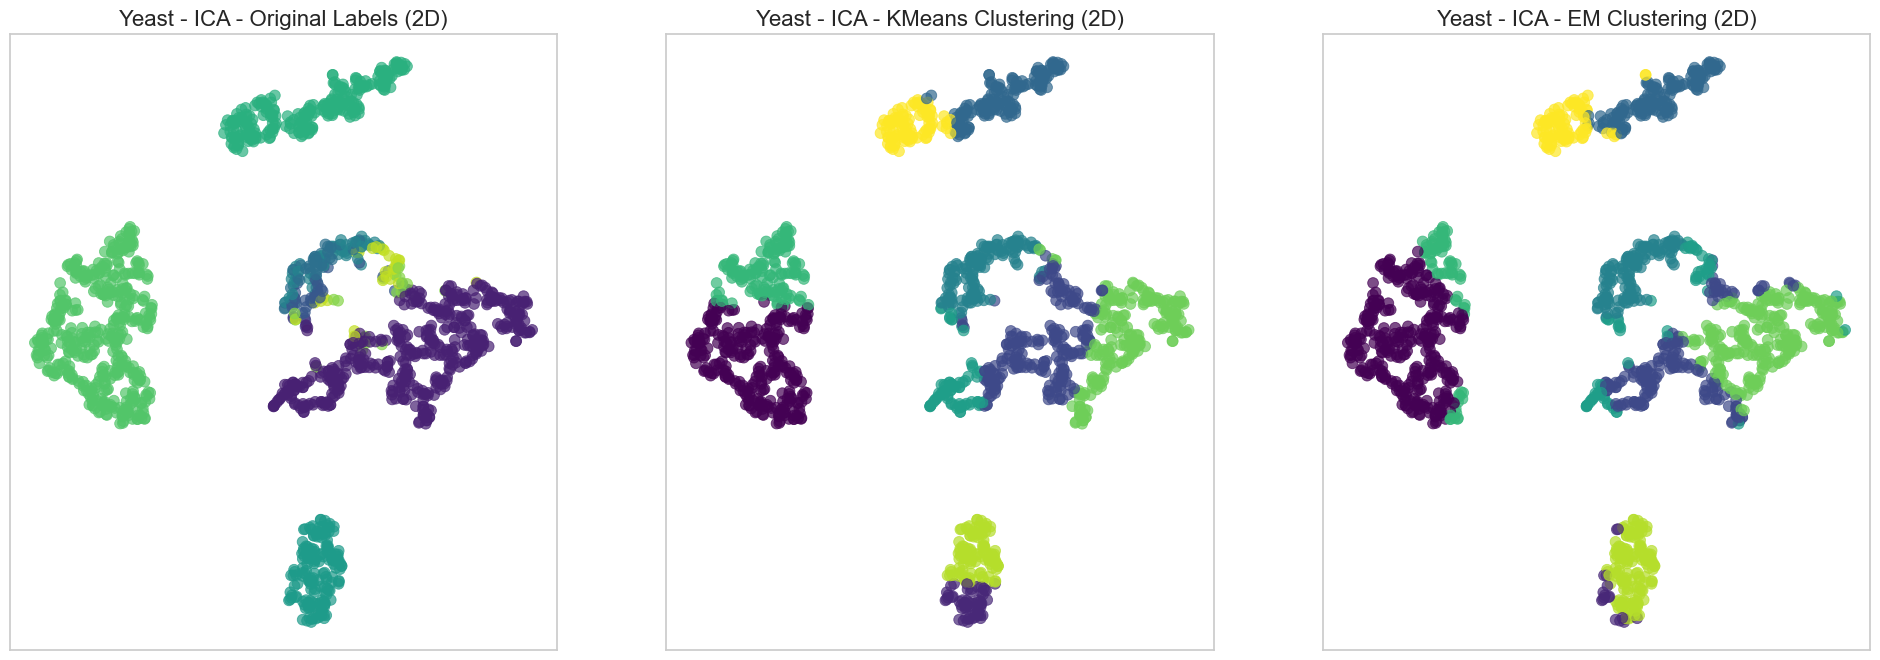

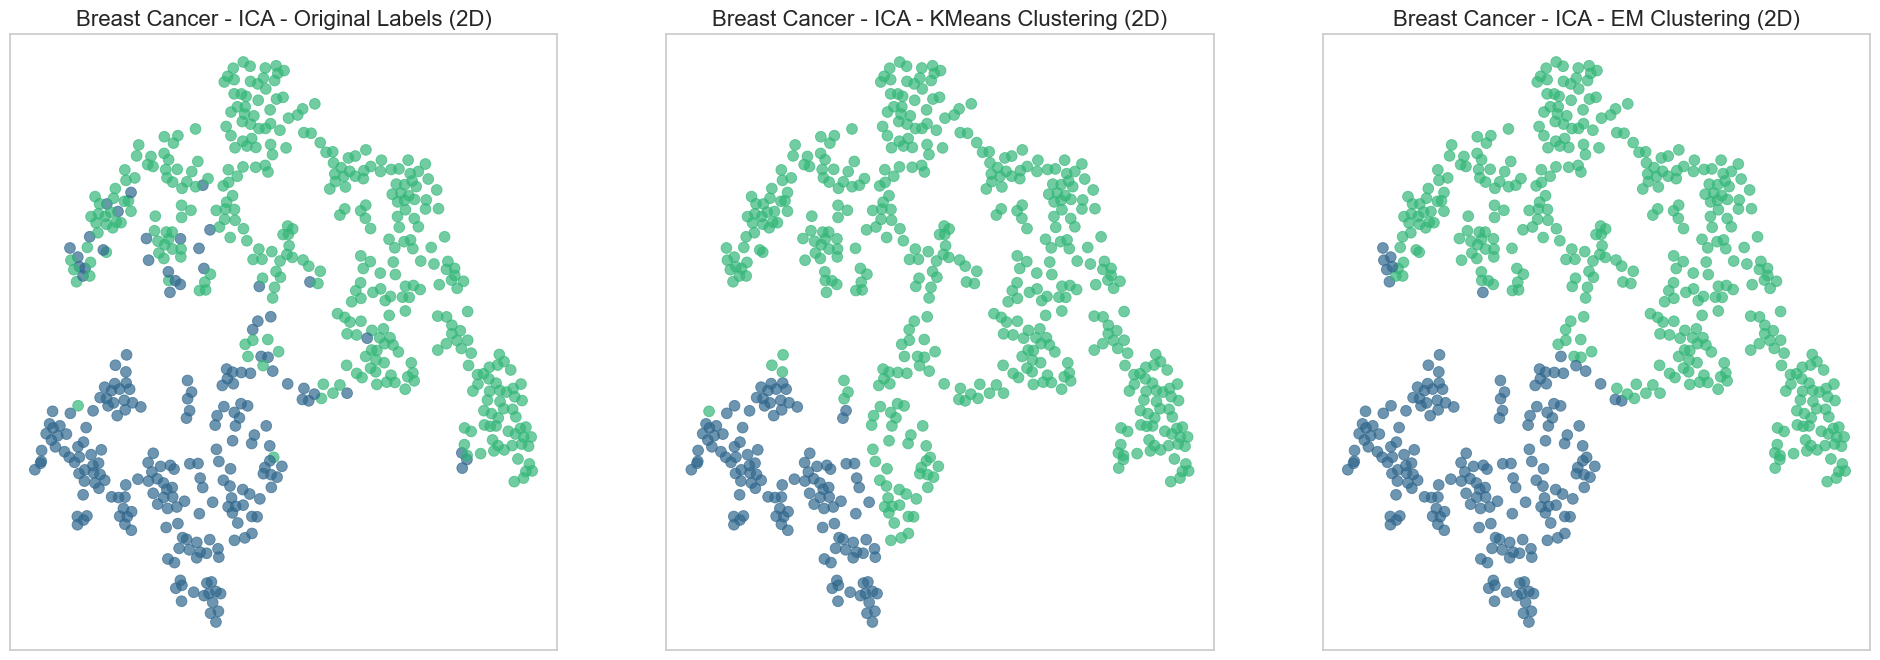

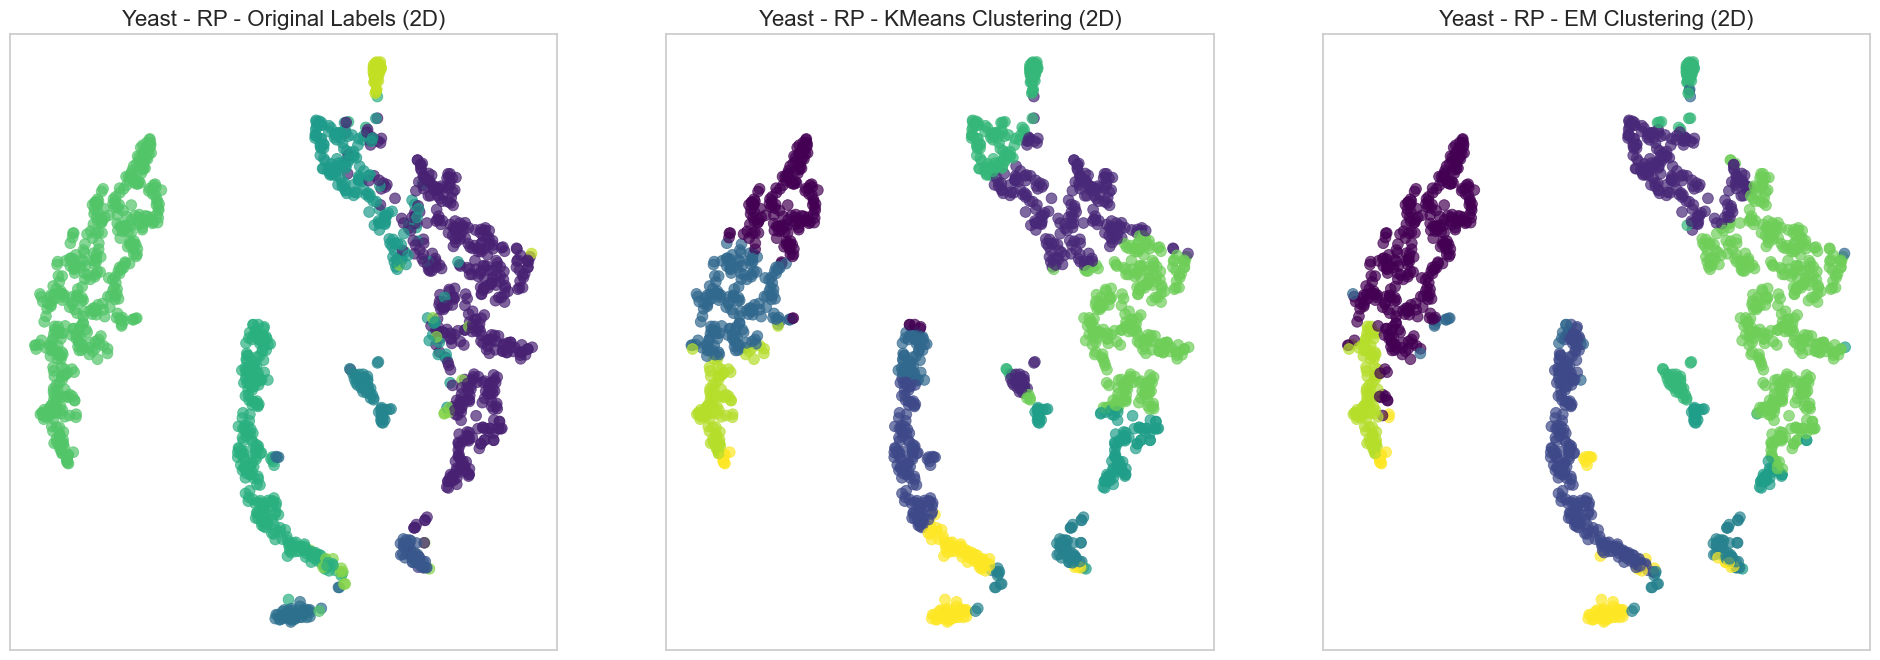

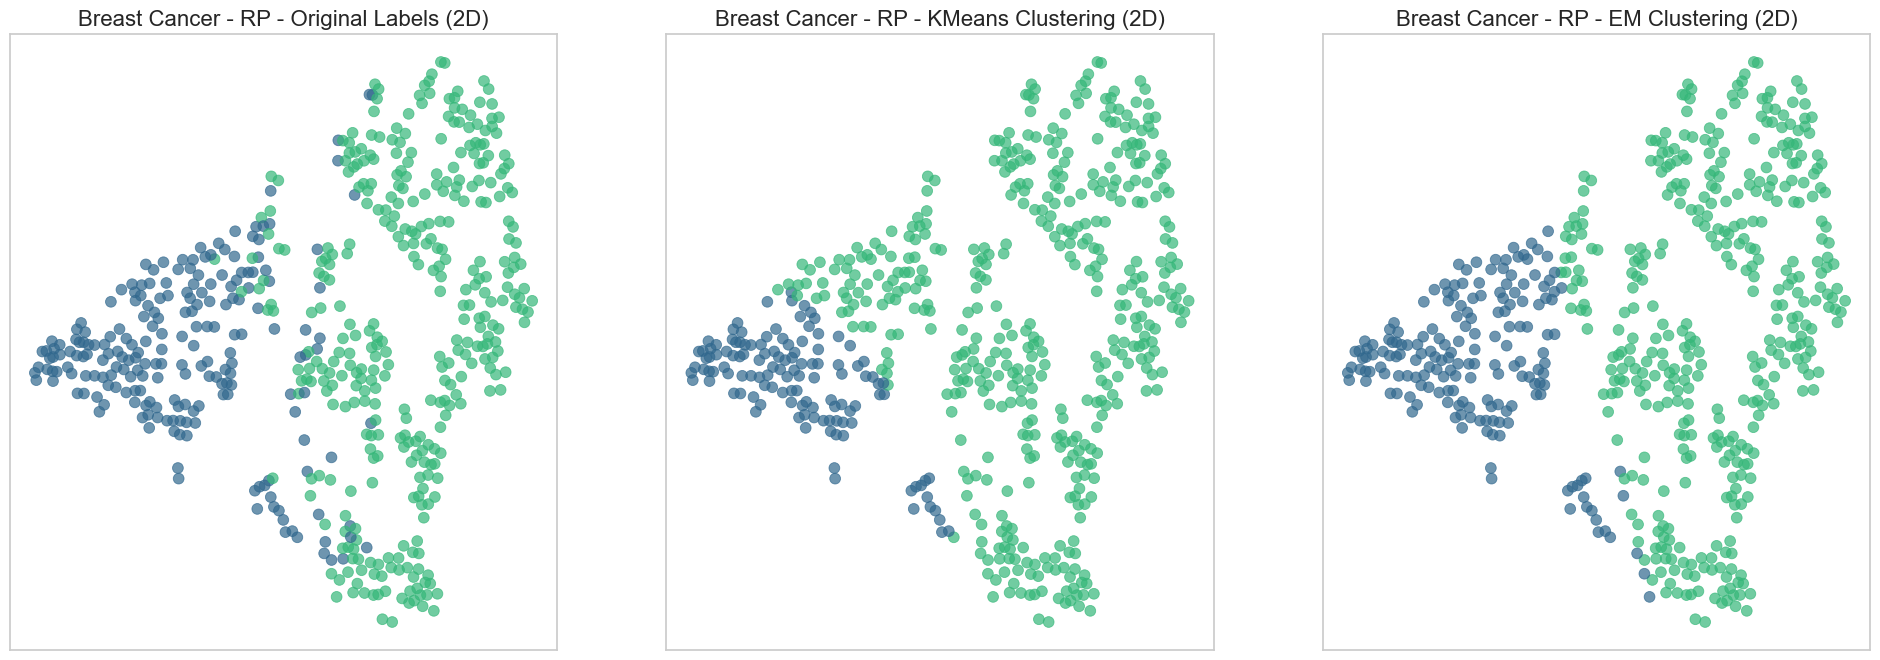

In [17]:
# %%
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.random_projection import GaussianRandomProjection

sns.set_theme(style="whitegrid")
os.makedirs("./result", exist_ok=True)

# Load the Yeast dataset
yeast_data = fetch_openml(data_id=181, as_frame=True)
yeast_df = yeast_data.frame
yeast_df["target"] = yeast_data.target

# Identify categorical columns
categorical_columns = yeast_df.select_dtypes(include=["category"]).columns
non_categorical_columns = yeast_df.select_dtypes(exclude=["category"]).columns

# One-hot encode categorical columns
yeast_features = pd.get_dummies(yeast_df, columns=categorical_columns, drop_first=True)
# join the non-categorical columns
yeast_features = pd.concat([yeast_features, yeast_df[non_categorical_columns]], axis=1)

# Separate features and target
yeast_target = yeast_df["target"]

# Load the Breast Cancer dataset (keeping this for comparison)
bc_data = load_breast_cancer()
bc_df = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
bc_df["target"] = bc_data.target


# Function to apply t-SNE and visualize in subplots
def tsne_visualization_subplots(
    data, original_labels, kmeans_labels, em_labels, title_prefix, filename_prefix
):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(data)

    fig, axs = plt.subplots(1, 3, figsize=(24, 8))

    sns.scatterplot(
        x=tsne_result[:, 0],
        y=tsne_result[:, 1],
        hue=original_labels,
        palette="viridis",
        ax=axs[0],
        legend=None,
        s=60,
        alpha=0.7,
        edgecolor=None,
    )
    axs[0].set_title(f"{title_prefix} - Original Labels (2D)", fontsize=16)
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[0].set_xlabel("")
    axs[0].set_ylabel("")

    sns.scatterplot(
        x=tsne_result[:, 0],
        y=tsne_result[:, 1],
        hue=kmeans_labels,
        palette="viridis",
        ax=axs[1],
        legend=None,
        s=60,
        alpha=0.7,
        edgecolor=None,
    )
    axs[1].set_title(f"{title_prefix} - KMeans Clustering (2D)", fontsize=16)
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    axs[1].set_xlabel("")
    axs[1].set_ylabel("")

    sns.scatterplot(
        x=tsne_result[:, 0],
        y=tsne_result[:, 1],
        hue=em_labels,
        palette="viridis",
        ax=axs[2],
        legend=None,
        s=60,
        alpha=0.7,
        edgecolor=None,
    )
    axs[2].set_title(f"{title_prefix} - EM Clustering (2D)", fontsize=16)
    axs[2].set_xticks([])
    axs[2].set_yticks([])
    axs[2].set_xlabel("")
    axs[2].set_ylabel("")

    plt.savefig(f"./result/{filename_prefix}_subplots.png")
    plt.show()


def apply_clustering(data, n_clusters):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(scaled_data)

    em = GaussianMixture(n_components=n_clusters, random_state=42)
    em_labels = em.fit_predict(scaled_data)

    return kmeans_labels, em_labels


# Function to compute reconstruction error
def compute_reconstruction_error(original, reduced, inverse_transformer):
    reconstructed = inverse_transformer.inverse_transform(reduced)
    error = np.mean((original - reconstructed) ** 2)
    return error


# Apply clustering to Yeast dataset
yeast_kmeans_labels, yeast_em_labels = apply_clustering(yeast_features, n_clusters=10)

# Apply clustering to Breast Cancer dataset
bc_kmeans_labels, bc_em_labels = apply_clustering(
    bc_df[bc_data.feature_names], n_clusters=2
)

# Dimensionality Reduction
pca = PCA(n_components=2)
yeast_pca = pca.fit_transform(yeast_features)
bc_pca = pca.fit_transform(bc_df[bc_data.feature_names])

ica = FastICA(n_components=2, random_state=42)
yeast_ica = ica.fit_transform(yeast_features)
bc_ica = ica.fit_transform(bc_df[bc_data.feature_names])

rp = GaussianRandomProjection(n_components=2, random_state=42)
yeast_rp = rp.fit_transform(yeast_features)
bc_rp = rp.fit_transform(bc_df[bc_data.feature_names])

# Clustering on reduced data
yeast_pca_kmeans_labels, yeast_pca_em_labels = apply_clustering(
    yeast_pca, n_clusters=10
)
yeast_ica_kmeans_labels, yeast_ica_em_labels = apply_clustering(
    yeast_ica, n_clusters=10
)
yeast_rp_kmeans_labels, yeast_rp_em_labels = apply_clustering(yeast_rp, n_clusters=10)

bc_pca_kmeans_labels, bc_pca_em_labels = apply_clustering(bc_pca, n_clusters=2)
bc_ica_kmeans_labels, bc_ica_em_labels = apply_clustering(bc_ica, n_clusters=2)
bc_rp_kmeans_labels, bc_rp_em_labels = apply_clustering(bc_rp, n_clusters=2)

# Visualizations for original data and clustering results
tsne_visualization_subplots(
    yeast_features,
    yeast_df["target"],
    yeast_kmeans_labels,
    yeast_em_labels,
    "Yeast - Original",
    "yeast_original",
)
tsne_visualization_subplots(
    bc_df[bc_data.feature_names],
    bc_df["target"],
    bc_kmeans_labels,
    bc_em_labels,
    "Breast Cancer - Original",
    "bc_original",
)

# Visualizations for PCA reduced data and clustering results
tsne_visualization_subplots(
    yeast_pca,
    yeast_df["target"],
    yeast_pca_kmeans_labels,
    yeast_pca_em_labels,
    "Yeast - PCA",
    "yeast_pca",
)
tsne_visualization_subplots(
    bc_pca,
    bc_df["target"],
    bc_pca_kmeans_labels,
    bc_pca_em_labels,
    "Breast Cancer - PCA",
    "bc_pca",
)

# Visualizations for ICA reduced data and clustering results
tsne_visualization_subplots(
    yeast_ica,
    yeast_df["target"],
    yeast_ica_kmeans_labels,
    yeast_ica_em_labels,
    "Yeast - ICA",
    "yeast_ica",
)
tsne_visualization_subplots(
    bc_ica,
    bc_df["target"],
    bc_ica_kmeans_labels,
    bc_ica_em_labels,
    "Breast Cancer - ICA",
    "bc_ica",
)

# Visualizations for RP reduced data and clustering results
tsne_visualization_subplots(
    yeast_rp,
    yeast_df["target"],
    yeast_rp_kmeans_labels,
    yeast_rp_em_labels,
    "Yeast - RP",
    "yeast_rp",
)
tsne_visualization_subplots(
    bc_rp,
    bc_df["target"],
    bc_rp_kmeans_labels,
    bc_rp_em_labels,
    "Breast Cancer - RP",
    "bc_rp",
)